In [ ]:
#Importar el drive para usar el dataset y carga de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from seaborn import violinplot
from sklearn.preprocessing import LabelEncoder


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Ruta del archivo en Google Drive
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    name=fn
counter = pd.read_csv(name, sep=";")

Saving Anexo ET_demo_round_traces_2022.csv to Anexo ET_demo_round_traces_2022.csv


/tmp/ipython-input-4-1161224160.py:6: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  counter = pd.read_csv(name, sep=";")


## Fase 3: Data Preparation

In [ ]:
counter_backup = counter.copy()

In [ ]:
counter_backup.drop(columns=['FirstKillTime'], inplace=True)
counter_backup.drop(columns=['TimeAlive'], inplace=True)
counter_backup.drop(columns=['TravelledDistance'], inplace=True)

### Eliminacion de datos atipicos

In [ ]:
counter_backup.drop(counter_backup[counter_backup['MatchKills'] > 28].index, inplace=True)
counter_backup.shape

(78995, 27)

In [ ]:
counter_backup.drop(counter_backup[counter_backup['MatchAssists'] > 8].index, inplace=True)
counter_backup.shape

(78710, 27)

In [ ]:
label_encoder = LabelEncoder()
counter_backup['Team'] = label_encoder.fit_transform(counter_backup['Team'])
counter_backup['Map'] = label_encoder.fit_transform(counter_backup['Map'])

In [ ]:
counter_backup['Map'].unique()

array([1, 3, 2, 0])

In [ ]:
counter_backup.RoundWinner = counter_backup.RoundWinner.astype(bool)
counter_backup.MatchWinner = counter_backup.MatchWinner.astype(bool)
# Conversion
counter_backup.RoundWinner.replace({True: 1, False: 0}, inplace=True)
counter_backup.MatchWinner.replace({True: 1, False: 0}, inplace=True)
counter_backup.Survived.replace({True: 1, False: 0}, inplace=True)

/tmp/ipython-input-11-2581591286.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  counter_backup.RoundWinner.replace({True: 1, False: 0}, inplace=True)
/tmp/ipython-input-11-2581591286.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  counter_backup.RoundWinner.replace({True: 1, False: 0}, inpl

In [ ]:
# Revisiom
counter_backup.info()
# Vista previa
counter_backup.head()

<class 'pandas.core.frame.DataFrame'>
Index: 78710 entries, 0 to 79156
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   78710 non-null  int64  
 1   Map                          78710 non-null  int64  
 2   Team                         78710 non-null  int64  
 3   InternalTeamId               78710 non-null  int64  
 4   MatchId                      78710 non-null  int64  
 5   RoundId                      78710 non-null  int64  
 6   RoundWinner                  78710 non-null  int64  
 7   MatchWinner                  78710 non-null  int64  
 8   Survived                     78710 non-null  int64  
 9   AbnormalMatch                78710 non-null  bool   
 10  RLethalGrenadesThrown        78710 non-null  int64  
 11  RNonLethalGrenadesThrown     78710 non-null  int64  
 12  PrimaryAssaultRifle          78710 non-null  float64
 13  PrimarySniperRifle   

,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,600,1,1,1,4,1,1,1,0,False,...,0,0,0,0,750,4400,0,0,0,0
1,601,1,1,1,4,1,1,1,0,False,...,0,0,0,0,800,4400,0,0,0,0
2,602,1,1,1,4,1,1,1,0,False,...,0,0,0,0,1000,4400,0,0,0,0
3,603,1,1,1,4,1,1,1,0,False,...,0,0,0,0,850,4400,0,0,0,0
4,604,1,1,1,4,1,1,1,1,False,...,0,0,0,0,1000,4400,0,0,0,0


In [ ]:
# Limitar numero de rondas
counter_backup = counter_backup[(counter_backup['RoundId'] >= 1) & (counter_backup['RoundId'] <= 30)]

counter_backup['RoundId'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

### Random forest

Modelo utilizado: Random Forest Regressor
MAE (Error absoluto medio): 0.50
MSE (Error cuadrático medio): 0.40
RMSE (Raíz cuadrada del MSE): 0.63
R² (Coef. de determinación): 0.851


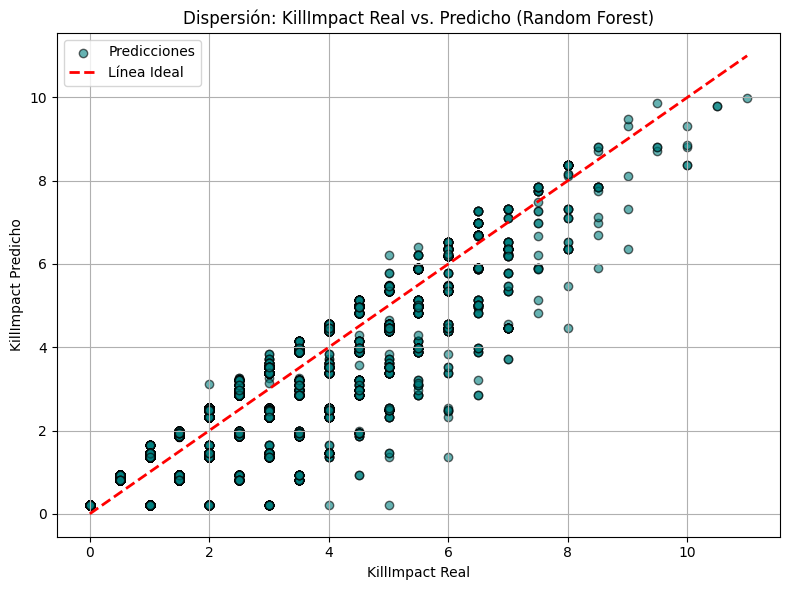

['KillImpact.pkl']

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

#Crear nueva columna derivada
counter_backup['KillImpact'] = counter_backup['RoundKills'] + 0.5 * counter_backup['RLethalGrenadesThrown']+ 0.5 * counter_backup['RNonLethalGrenadesThrown'] + counter_backup['RoundHeadshots']


#Función para convertir valores numéricos mal formateados (de tipo texto) a flotantes
def to_float(value):
    if isinstance(value, str):
        value = value.replace('.', '').replace(',', '.')
        try:
            return float(value)
        except:
            return np.nan
    return value

#Aplicar esta limpieza a ciertas columnas
columns_to_convert = [  'RoundHeadshots', 'KillImpact','RNonLethalGrenadesThrown','RLethalGrenadesThrown']
for column in columns_to_convert:
    counter_backup[column] = counter_backup[column].apply(to_float)

counter_backup.dropna(subset=columns_to_convert, inplace=True)


X = counter_backup[[ 'RoundHeadshots','RNonLethalGrenadesThrown','RLethalGrenadesThrown']]
y = counter_backup['KillImpact']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


modelo_rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred = modelo_rf.predict(X_test)

#Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)       # Error absoluto medio
mse = mean_squared_error(y_test, y_pred)        # Error cuadrático medio
rmse = np.sqrt(mse)                             # Raíz del MSE
r2 = r2_score(y_test, y_pred)                   # Coeficiente de determinación R²

# Mostrar resultados
print("Modelo utilizado: Random Forest Regressor")
print(f"MAE (Error absoluto medio): {mae:.2f}")
print(f"MSE (Error cuadrático medio): {mse:.2f}")
print(f"RMSE (Raíz cuadrada del MSE): {rmse:.2f}")
print(f"R² (Coef. de determinación): {r2:.3f}")


# Gráfico de dispersión: Valores reales vs. valores predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolor='k', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Línea Ideal')
plt.title('Dispersión: KillImpact Real vs. Predicho (Random Forest)')
plt.xlabel('KillImpact Real')
plt.ylabel('KillImpact Predicho')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Tu modelo entrenado (ya deberías tenerlo):
from sklearn.ensemble import RandomForestRegressor

# X = features, y = RoundWinner
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X, y)

# Guarda el modelo entrenado
joblib.dump(rf_model, 'KillImpact.pkl')

In [20]:
from google.colab import files
files.download('KillImpact.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>